In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
gt_train_path = os.path.join(base_path, 'gt_train.csv')

# Load the data
cols = ['image_id', 'label', 'x1', 'y1', 'x2', 'y2']
df = pd.read_csv(gt_train_path, names=cols, header=None, dtype={'image_id': str})

print(f"Total annotations: {len(df)}")
print(f"Total unique images: {df['image_id'].nunique()}")
df.head()

Total annotations: 351549
Total unique images: 110000


,image_id,label,x1,y1,x2,y2
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


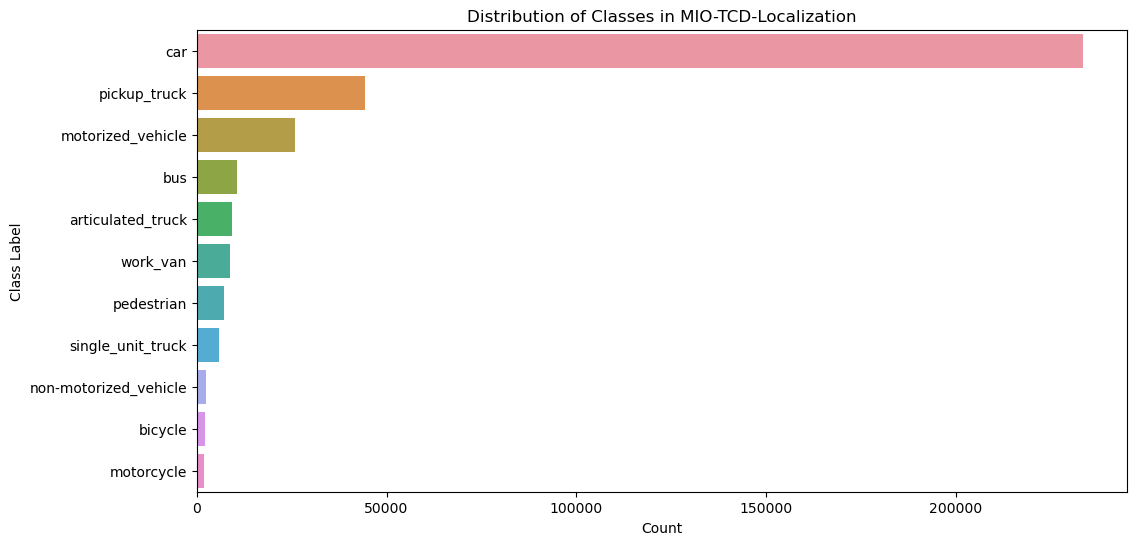

Class Counts:
label
car                      233497
pickup_truck              44283
motorized_vehicle         25845
bus                       10598
articulated_truck          9301
work_van                   8709
pedestrian                 7128
single_unit_truck          5741
non-motorized_vehicle      2350
bicycle                    2260
motorcycle                 1837
Name: count, dtype: int64


In [2]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Distribution of Classes in MIO-TCD-Localization')
plt.xlabel('Count')
plt.ylabel('Class Label')
plt.show()

print("Class Counts:")
print(df['label'].value_counts())

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


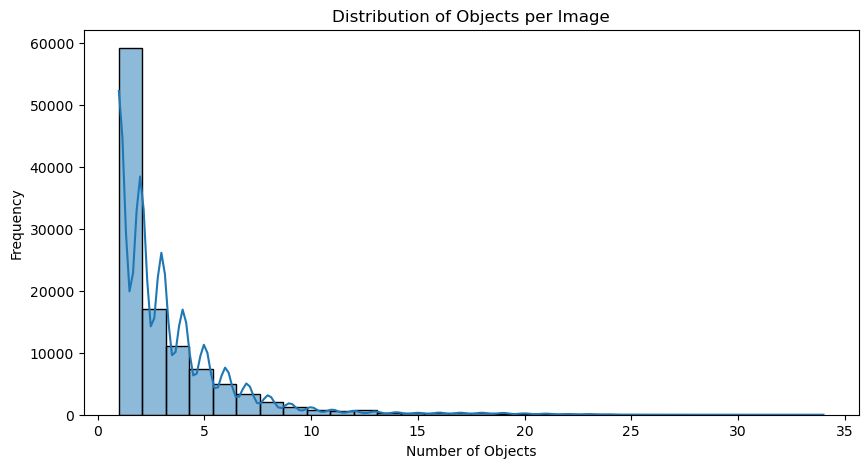

Average objects per image: 3.20
Max objects in an image: 34


In [3]:
objects_per_image = df.groupby('image_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(objects_per_image, bins=30, kde=True)
plt.title('Distribution of Objects per Image')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()

print(f"Average objects per image: {objects_per_image.mean():.2f}")
print(f"Max objects in an image: {objects_per_image.max()}")

## Most object count image visualized

Image with highest object count: 00022157
Number of objects: 34
Loading image from:
C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\train\00022157.jpg


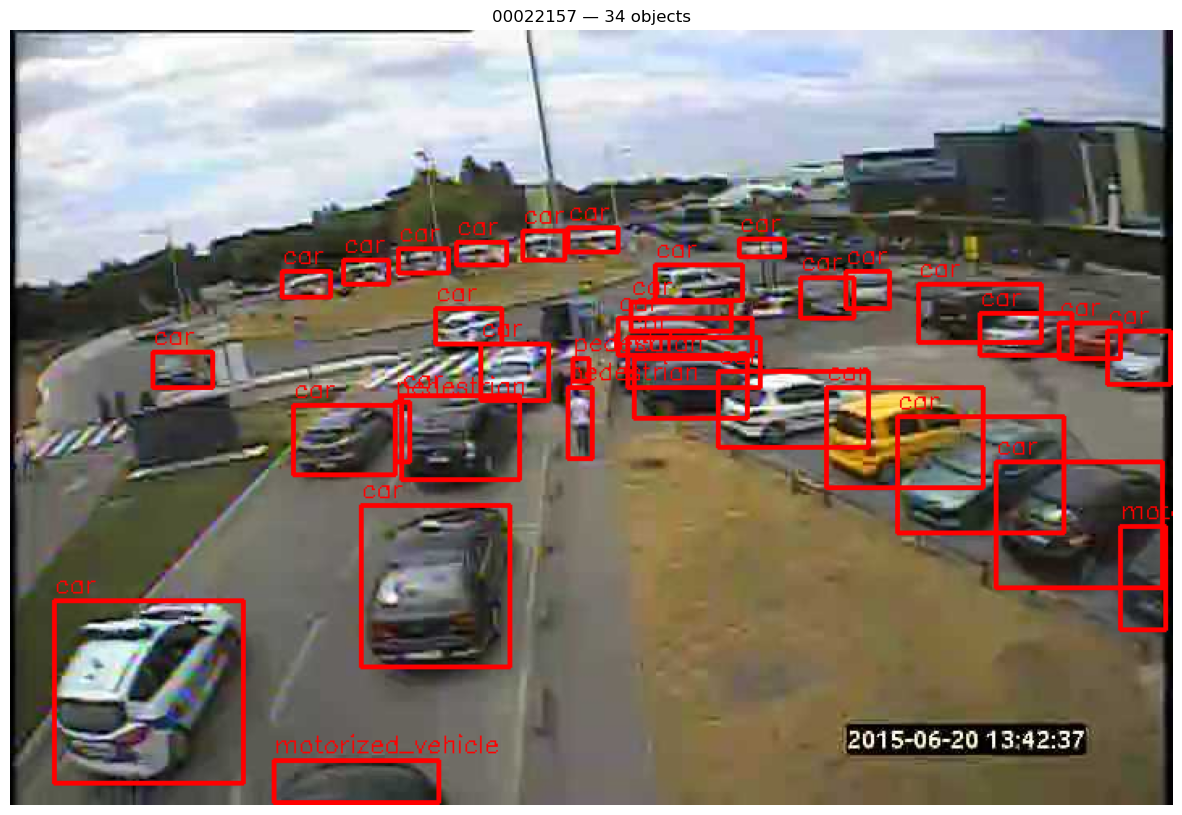

In [4]:
import cv2
import matplotlib.pyplot as plt

# Find image with max objects
objects_per_image = df.groupby('image_id').size()

max_count = objects_per_image.max()
max_image_id = objects_per_image.idxmax()

print(f"Image with highest object count: {max_image_id}")
print(f"Number of objects: {max_count}")

# Images folder
images_path = os.path.join(base_path, 'train')

# Add image extension
img_filename = max_image_id + '.jpg'

# Full image path
img_path = os.path.join(images_path, img_filename)

print("Loading image from:")
print(img_path)

# Load image
img = cv2.imread(img_path)

# Check if image loaded correctly
if img is None:
    print("ERROR: Image not found.")
else:
    # Convert BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get bounding boxes for this image
    img_boxes = df[df['image_id'] == max_image_id]

    # Draw boxes
    for _, row in img_boxes.iterrows():
        x1, y1, x2, y2 = map(int, [row['x1'], row['y1'], row['x2'], row['y2']])
        label = row['label']

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        cv2.putText(
            img,
            str(label),
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

    # Display image
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.title(f"{max_image_id} — {max_count} objects")
    plt.axis('off')
    plt.show()

In [9]:
import pandas as pd
import numpy as np

# Continuing from your notebook's df_vehicles
vehicle_counts = df_vehicles.groupby('image_id').size().reset_index(name='vehicle_count')

# Use tertiles so classes are balanced — adjust if your distribution is skewed
low_thresh, high_thresh = vehicle_counts['vehicle_count'].quantile([0.33, 0.66])
print(f"Low/Medium boundary: {low_thresh:.1f} vehicles")
print(f"Medium/High boundary: {high_thresh:.1f} vehicles")

def bin_congestion(count):
    if count <= low_thresh:
        return 0  # Low
    elif count <= high_thresh:
        return 1  # Medium
    else:
        return 2  # High

vehicle_counts['congestion_label'] = vehicle_counts['vehicle_count'].apply(bin_congestion)
print(vehicle_counts['congestion_label'].value_counts())

# This becomes your single source of truth — one row per image
vehicle_counts.to_csv('congestion_labels.csv', index=False)

Low/Medium boundary: 2.0 vehicles
Medium/High boundary: 3.0 vehicles
congestion_label
0    60133
2    33094
1    16761
Name: count, dtype: int64


In [11]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split

In [12]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split

# --- Paths ---
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
labels_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\congestion_labels.csv"
image_dir = os.path.join(base_path, "train")

# --- Load precomputed congestion labels ---
vehicle_counts = pd.read_csv(labels_path, dtype={'image_id': str})
print(vehicle_counts.head())
print(vehicle_counts['congestion_label'].value_counts())

# --- Dataset class ---
class MIOTCDCongestionDataset(Dataset):
    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = int(row['congestion_label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# --- Stratified subset + split ---
subset = vehicle_counts.groupby('congestion_label').sample(n=2000, random_state=42)

train_df, temp_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['congestion_label'], random_state=42
)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

train_ds = MIOTCDCongestionDataset(train_df, image_dir, transform)
val_ds   = MIOTCDCongestionDataset(val_df, image_dir, transform)
test_ds  = MIOTCDCongestionDataset(test_df, image_dir, transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# --- Model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- Training loop ---
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val accuracy: {correct/total:.2%}")

os.makedirs('models', exist_ok=True)
torch.save(model, 'models/baseline_v1.pt')

   image_id  vehicle_count  congestion_label
0  00000000              5                 2
1  00000001              6                 2
2  00000002              1                 0
3  00000003              2                 0
4  00000004              1                 0
congestion_label
0    60133
2    33094
1    16761
Name: count, dtype: int64
Train: 4200 | Val: 900 | Test: 900
Epoch 1 | Val accuracy: 71.56%



KeyboardInterrupt



In [1]:
# --- Smaller stratified subset for fast iteration ---
subset = vehicle_counts.groupby('congestion_label').sample(n=200, random_state=42)
# 200 per class × 3 classes = 600 images total (vs 6000 before)

train_df, temp_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['congestion_label'], random_state=42
)

train_ds = MIOTCDCongestionDataset(train_df, image_dir, transform)
val_ds   = MIOTCDCongestionDataset(val_df, image_dir, transform)
test_ds  = MIOTCDCongestionDataset(test_df, image_dir, transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

NameError: name 'vehicle_counts' is not defined

In [ ]:
# --- Faster training: fewer epochs, smaller batch if low on RAM ---
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, num_workers=0)

for epoch in range(3):   # 3 epochs instead of 10
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val accuracy: {correct/total:.2%}")

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split

# --- Paths ---
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
labels_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\congestion_labels.csv"
image_dir = os.path.join(base_path, "train")

# --- Load precomputed congestion labels ---
vehicle_counts = pd.read_csv(labels_path, dtype={'image_id': str})
print(vehicle_counts.head())
print(vehicle_counts['congestion_label'].value_counts())

# --- Dataset class ---
class MIOTCDCongestionDataset(Dataset):
    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = int(row['congestion_label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# --- Smaller stratified subset for fast iteration ---
subset = vehicle_counts.groupby('congestion_label').sample(n=200, random_state=42)
# 200 per class × 3 classes = 600 images total

train_df, temp_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['congestion_label'], random_state=42
)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

train_ds = MIOTCDCongestionDataset(train_df, image_dir, transform)
val_ds   = MIOTCDCongestionDataset(val_df, image_dir, transform)
test_ds  = MIOTCDCongestionDataset(test_df, image_dir, transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# --- Model: ResNet-18 (lighter + faster than ResNet-50) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, num_workers=0)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- Training loop ---
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val accuracy: {correct/total:.2%}")

os.makedirs('models', exist_ok=True)
torch.save(model, 'models/baseline_v1.pt')

   image_id  vehicle_count  congestion_label
0  00000000              5                 2
1  00000001              6                 2
2  00000002              1                 0
3  00000003              2                 0
4  00000004              1                 0
congestion_label
0    60133
2    33094
1    16761
Name: count, dtype: int64
Train: 420 | Val: 90 | Test: 90


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Dell/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:07<00:00, 6.11MB/s]


Epoch 1 | Val accuracy: 58.89%
Epoch 2 | Val accuracy: 54.44%
Epoch 3 | Val accuracy: 66.67%
Epoch 4 | Val accuracy: 61.11%
Epoch 5 | Val accuracy: 61.11%


In [3]:
!pip install adversarial-robustness-toolbox

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
    --------------------------------------- 0.0/1.1 MB 682.7 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.1 MB 2.3 MB/s eta 0:00:01
   ---------- ----------------------------- 0.3/1.1 MB 2.5 MB/s eta 0:00:01
   -------------- ------------------------- 0.4/1.1 MB 2.5 MB/s eta 0:00:01
   -------------------- ------------------- 0.6/1.1 MB 3.0 MB/s eta 0:00:01
   --------------------------------- ------ 0.9/1.1 MB 3.7 MB/s eta 0:00:01
   -------------------------------------- - 1.1/1.1 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 3.5 MB/s eta 0:00:00


In [4]:
pip install torch torchvision adversarial-robustness-toolbox pandas scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split

# --- Paths ---
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
labels_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\congestion_labels.csv"
image_dir = os.path.join(base_path, "train")

vehicle_counts = pd.read_csv(labels_path, dtype={'image_id': str})

# --- TINY subset: 10 images per class = 30 total ---
subset = vehicle_counts.groupby('congestion_label').sample(n=10, random_state=42)
train_df, test_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)

transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])

class MIOTCDCongestionDataset(Dataset):
    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = int(row['congestion_label'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = MIOTCDCongestionDataset(train_df, image_dir, transform)
test_ds  = MIOTCDCongestionDataset(test_df, image_dir, transform)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- 2 epochs only — just enough to move off random weights ---
for epoch in range(2):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done")

os.makedirs('models', exist_ok=True)
torch.save(model, 'models/baseline_v1.pt')
print("Model saved.")

# --- FGSM attack, immediately, on the tiny test set ---
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

model.eval()
classifier = PyTorchClassifier(
    model=model, loss=criterion, optimizer=optimizer,
    input_shape=(3, 224, 224), nb_classes=3,
    clip_values=(0.0, 1.0),
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
x_test_list, y_test_list = [], []
for images, labels in test_loader:
    x_test_list.append(images.numpy())
    y_test_list.append(labels.numpy())
x_test = np.concatenate(x_test_list)
y_test = np.concatenate(y_test_list)

clean_preds = np.argmax(classifier.predict(x_test), axis=1)
clean_acc = np.mean(clean_preds == y_test)
print(f"Clean accuracy: {clean_acc:.2%}")

epsilons = [0.01, 0.05, 0.10, 0.20]
results = []
for eps in epsilons:
    attack = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = attack.generate(x=x_test)
    adv_preds = np.argmax(classifier.predict(x_adv), axis=1)
    acc = np.mean(adv_preds == y_test)
    asr = np.mean(adv_preds != clean_preds)
    results.append({'eps': eps, 'attacked_acc': acc, 'asr': asr})
    print(f"ε={eps} | Accuracy: {acc:.2%} | ASR: {asr:.2%}")

os.makedirs('outputs', exist_ok=True)
pd.DataFrame(results).to_csv('outputs/fgsm_results.csv', index=False)
print("Done. Results saved to outputs/fgsm_results.csv")

Train: 21 | Test: 9
Epoch 1 done
Epoch 2 done
Model saved.
Clean accuracy: 22.22%
ε=0.01 | Accuracy: 66.67% | ASR: 100.00%
ε=0.05 | Accuracy: 66.67% | ASR: 100.00%
ε=0.1 | Accuracy: 66.67% | ASR: 100.00%
ε=0.2 | Accuracy: 33.33% | ASR: 33.33%
Done. Results saved to outputs/fgsm_results.csv


Saved 9 adversarial images to outputs/adversarial_images/
Saved x_adv.npy and y_test.npy for defence model training


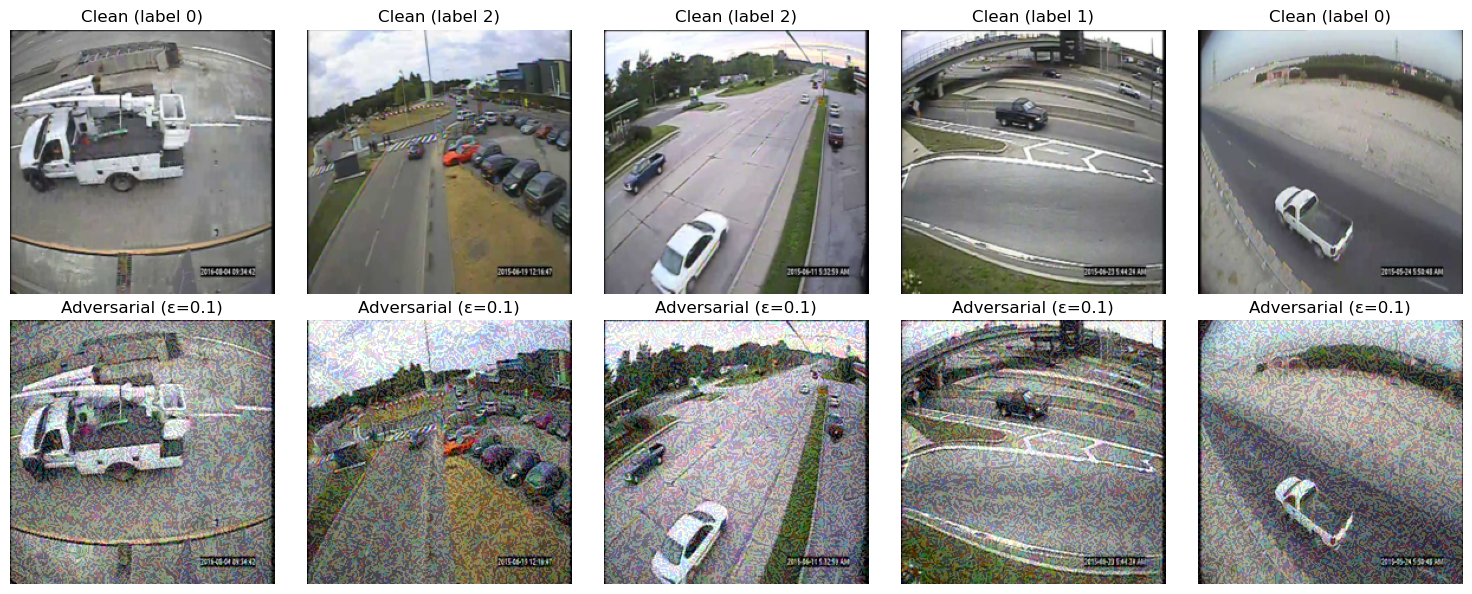

Saved comparison grid to outputs/fgsm_comparison.png


In [14]:
# --- Generate and SAVE the adversarial images (not just metrics) ---
import matplotlib.pyplot as plt

# Pick the epsilon you want to use for the defence dataset
eps_for_defence = 0.10
attack = FastGradientMethod(estimator=classifier, eps=eps_for_defence)
x_adv = attack.generate(x=x_test)   # shape: (N, 3, 224, 224), values in [0,1]

os.makedirs('outputs/adversarial_images', exist_ok=True)

# Save every adversarial image as a .png file
for i in range(len(x_adv)):
    img_array = x_adv[i].transpose(1, 2, 0)        # CHW -> HWC for saving
    img_array = (img_array * 255).astype(np.uint8) # back to 0-255 range
    Image.fromarray(img_array).save(
        f'outputs/adversarial_images/adv_{i}_label{y_test[i]}.png'
    )

print(f"Saved {len(x_adv)} adversarial images to outputs/adversarial_images/")

# Also save as a single .npy file — easiest format to reload for training a defence model
np.save('outputs/adversarial_images/x_adv.npy', x_adv)
np.save('outputs/adversarial_images/y_test.npy', y_test)
print("Saved x_adv.npy and y_test.npy for defence model training")

# Optional: visualise a few clean vs adversarial pairs side by side
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    clean_img = x_test[i].transpose(1, 2, 0)
    adv_img   = x_adv[i].transpose(1, 2, 0)
    axes[0, i].imshow(clean_img)
    axes[0, i].set_title(f"Clean (label {y_test[i]})")
    axes[0, i].axis('off')
    axes[1, i].imshow(adv_img)
    axes[1, i].set_title(f"Adversarial (ε={eps_for_defence})")
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('outputs/fgsm_comparison.png')
plt.show()
print("Saved comparison grid to outputs/fgsm_comparison.png")